# 01 — Preprocessing & Labeling Sentimen Komentar YouTube

Notebook ini melakukan preprocessing teks pada dataset komentar YouTube (`dataset1.csv`) dan pelabelan sentimen awal menggunakan leksikon **SenticNet**.

---

## Alur Notebook
1. **Install & Import** — library yang dibutuhkan
2. **Load Dataset** — baca `dataset1.csv` dari Google Drive
3. **Cleaning** — hapus URL, mention, hashtag, angka, karakter non-ASCII
4. **Normalisasi** — perbaiki kata tidak baku dengan `kamus_normalisasi.csv`
5. **Tokenisasi** — pecah teks menjadi token
6. **Stopword Removal** — hapus kata umum (Sastrawi + custom)
7. **Stemming** — bentuk dasar kata dengan Sastrawi
8. **Labeling Sentimen** — positif/negatif via SenticNet
9. **Visualisasi** — distribusi label & wordcloud

> **Output:** `hasil_stemming.csv` dan `sentimen hasil labeling TA.csv`

In [ ]:
## 1. Install Library


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00


In [ ]:
!pip install sastrawi emoji stopword imbalanced-learn nltk wordcloud -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import string
import emoji
import stopword
import Sastrawi
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from google.colab import drive
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 2. Load Dataset


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/capstone/dataset1.csv', encoding='utf-8')
print(f'Total data: {len(df)} baris')
print(f'Kolom: {df.columns.tolist()}')
df.head()

,author,text,published_at
0,@bumikita6990,kek mirip dokter tirta nggak si?,2026-04-17T13:40:54Z
1,@VịceNõd,Halo saya mau bagi stres yang akan di perbaiki...,2026-04-12T11:58:19Z
2,@belerick.r,Masuk bgt ini bikin wawasan luas dan meranjak ...,2026-04-12T04:57:57Z
3,@ParadaGurning,Manttap,2026-04-08T08:41:43Z
4,@raditcs,"ini ngebantu banget sih bang Radit, aku sebaga...",2026-04-07T05:51:39Z
...,...,...,...
5978,@zafirahadhiyanti,"Satu persen, request gimana cara ngatur rasa m...",2020-12-24T12:01:49Z
5979,@aegiss4755,"Gw penasaran, dialog video ini pake skrip atau...",2020-12-24T12:01:19Z
5980,@Sams_Inah,Ketawany nular woe! Wkwkkkk,2020-12-24T11:42:30Z
5981,@nurjayasn,Terimakasih 1 perseeen,2020-12-24T11:41:29Z


## 3. Preprocessing Teks


### 3.1 Cleaning


In [ ]:
print(df.columns)

Index(['author', 'text', 'published_at'], dtype='object')


In [ ]:
#Hapus kolom yang tidak diperlukan
df = df.drop(columns = ['published_at','author'])
df

,text
0,kek mirip dokter tirta nggak si?
1,Halo saya mau bagi stres yang akan di perbaiki...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...
3,Manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga..."
...,...
5978,"Satu persen, request gimana cara ngatur rasa m..."
5979,"Gw penasaran, dialog video ini pake skrip atau..."
5980,Ketawany nular woe! Wkwkkkk
5981,Terimakasih 1 perseeen


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'<a\s+href="[^"]*">?', '', text)  # hapus tag <a>
    text = re.sub(r'http\S+', '', text)  # hapus URL
    text = re.sub(r'<br\s*/?>', '', text)  # hapus <br>
    text = re.sub(r'&\w+;', '', text)  # hapus HTML entities
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # hapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # hapus hashtag
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # hapus tanda baca
    text = re.sub(r'\s+', ' ', text)  # hapus spasi berlebih
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # hapus karakter non-ASCII
    return text.strip()

# Terapkan fungsi pembersihan
df['clean_text'] = df['text'].apply(clean_text)

# Hapus nilai kosong atau hanya spasi
df = df[df['clean_text'].str.strip() != '']

# Hapus duplikat berdasarkan kolom clean_text
df = df.drop_duplicates(subset='clean_text').reset_index(drop=True)

df

,text,clean_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...
3,Manttap,Manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...
...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen


In [ ]:
df[['clean_text']].to_csv('Hasil_CleanText.csv', index=False)

In [ ]:
#lower case
def casefolding(text) :
  text = text.lower()
  return text

df['lower_text'] = df['clean_text'].apply(casefolding)
df

,text,clean_text,lower_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...
3,Manttap,Manttap,manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...
...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen


In [ ]:
df[['lower_text']].to_csv('Hasil_LowerText.csv', index=False)

### 3.2 Normalisasi Kata Tidak Baku


In [ ]:
import re

# Fungsi untuk mengganti kata tidak baku dalam teks dengan kata baku dari kamus
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = re.findall(r'\b\w+\b', text)

        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]

                # Pastikan baku_word adalah string
                if isinstance(baku_word, str):
                    replaced_words.extend(baku_word.split())
                else:
                    # Jika bukan string, ubah ke string atau abaikan
                    replaced_words.append(str(baku_word))

                kalimat_baku.append(baku_word)
                kata_diganti.append(word)
                kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)

        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash


In [ ]:
#definisikan kamus
kamus = pd.read_csv('kamus_normalisasi.csv')
kamus_tidak_baku = dict(zip(kamus['words'], kamus['kata baku']))
kamus

,words,kata baku
0,yg,yang
1,gak,tidak
2,alloh,allah
3,ga,tidak
4,tdk,tidak
...,...,...
8219,alaram,alarm
8220,alatya,alatnya
8221,zinaah,berzina
8222,zinah,berzina


In [ ]:
# Terapkan fungsi penggantian kata tidak baku
df['normalize_text'], df['Kata_Baku'], df['kata_tidak_baku'], df['Kata_Tidak_Baku_Hash'] = zip(*df['lower_text'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))


df =  pd.DataFrame(df[['text','clean_text','lower_text','normalize_text']])
df

,text,clean_text,lower_text,normalize_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...
3,Manttap,Manttap,manttap,manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...
...,...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen


In [ ]:
df[['normalize_text']].to_csv('Hasil_NormalizeText.csv', index=False)

### 3.3 Tokenisasi


In [ ]:
nltk.download('punkt_tab')
df['tokenized_text'] = df['normalize_text'].apply(word_tokenize)
df

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text,clean_text,lower_text,normalize_text,tokenized_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"[seperti, mirip, dokter, tirta, tidak, si]"
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"[halo, saya, mau, bagi, stres, yang, akan, di,..."
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"[masuk, banget, ini, bikin, wawasan, luas, dan..."
3,Manttap,Manttap,manttap,manttap,[manttap]
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"[ini, ngebantu, banget, sih, bang, radit, aku,..."
...,...,...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"[satu, persen, permintaan, gimana, cara, ngatu..."
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"[saya, penasaran, dialog, video, ini, pakai, s..."
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]"
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]"


In [ ]:
df[['tokenized_text']].to_csv('tokenized_text.csv', index=False)

### 3.4 Stopword Removal


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Load stopwords dari file CSV
custom_stopwords_df = pd.read_csv('kamus_stopword.csv')
custom_stopwords = set(custom_stopwords_df['word'].dropna().tolist())

# Daftar kata yang tidak boleh dihapus (exceptions)
exception_words = {'tolong', 'tidak', 'bisa','ada'}

# Buat objek stopword remover dari Sastrawi
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())

# Hapus kata exception dari daftar stopword bawaan dan custom
sastrawi_stopwords -= exception_words
custom_stopwords -= exception_words

# Gabungkan semua stopword yang telah dibersihkan dari exception
all_stopwords = sastrawi_stopwords.union(custom_stopwords)

# Fungsi pemrosesan teks
def proces_text(text):
    if isinstance(text, list):  # Kalau berupa list token
        text = ' '.join(text)
    words = text.split()
    filtered_words = [word for word in words if word not in all_stopwords]
    return ' '.join(filtered_words)

# Terapkan ke DataFrame
df['stopword_text'] = df['tokenized_text'].apply(proces_text)

In [ ]:
df['stopword_text'].to_csv('stopword.csv', index = False)

In [ ]:
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"[seperti, mirip, dokter, tirta, tidak, si]",mirip dokter tirta tidak
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"[halo, saya, mau, bagi, stres, yang, akan, di,...",halo mau stres perbaiki dokter wanita tercinta...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"[masuk, banget, ini, bikin, wawasan, luas, dan...",masuk banget bikin wawasan luas meranjak petun...
3,Manttap,Manttap,manttap,manttap,[manttap],manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"[ini, ngebantu, banget, sih, bang, radit, aku,...",ngebantu banget radit aku radit ytang gapunya ...
...,...,...,...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"[satu, persen, permintaan, gimana, cara, ngatu...",satu persen permintaan gimana cara ngatur rasa...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"[saya, penasaran, dialog, video, ini, pakai, s...",penasaran dialog video pakai skrip tidak saoln...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]",ketawany nular woe wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]",terimakasih perseeen


### 3.5 Stemming


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

#Define StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text_cleanning) :
  text = stemmer.stem(text_cleanning)
  return text

df['stemming_text'] = df['stopword_text'].apply(stemming)
df


,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"[seperti, mirip, dokter, tirta, tidak, si]",mirip dokter tirta tidak,mirip dokter tirta tidak
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"[halo, saya, mau, bagi, stres, yang, akan, di,...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"[masuk, banget, ini, bikin, wawasan, luas, dan...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...
3,Manttap,Manttap,manttap,manttap,[manttap],manttap,manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"[ini, ngebantu, banget, sih, bang, radit, aku,...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...
...,...,...,...,...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"[satu, persen, permintaan, gimana, cara, ngatu...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"[saya, penasaran, dialog, video, ini, pakai, s...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]",terimakasih perseeen,terimakasih perseeen


In [ ]:
#hilangkan Nan
df = df.dropna(subset = ['stemming_text'])

#hilangkan string kosong atau spasi saja
df = df[df['stemming_text'].str.strip() != '']

In [ ]:
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"[seperti, mirip, dokter, tirta, tidak, si]",mirip dokter tirta tidak,mirip dokter tirta tidak
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"[halo, saya, mau, bagi, stres, yang, akan, di,...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"[masuk, banget, ini, bikin, wawasan, luas, dan...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...
3,Manttap,Manttap,manttap,manttap,[manttap],manttap,manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"[ini, ngebantu, banget, sih, bang, radit, aku,...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...
...,...,...,...,...,...,...,...
5747,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"[satu, persen, permintaan, gimana, cara, ngatu...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...
5748,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"[saya, penasaran, dialog, video, ini, pakai, s...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...
5749,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk
5750,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]",terimakasih perseeen,terimakasih perseeen


In [ ]:
#import hasil stemming ke csv
df.to_csv('hasil_stemming.csv', index = False)

In [ ]:
df = pd.read_csv('hasil_stemming.csv')

## 4. Labeling Sentimen (SenticNet)


In [ ]:
#import senticnet
label_xls = pd.read_excel('senticnet.xlsx')
label_df = pd.DataFrame(label_xls)
lexicon_dict = dict(zip(label_df['CONCEPT'], label_df['POLARITY INTENSITY']))

In [ ]:
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"['seperti', 'mirip', 'dokter', 'tirta', 'tidak...",mirip dokter tirta tidak,mirip dokter tirta tidak
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"['halo', 'saya', 'mau', 'bagi', 'stres', 'yang...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"['masuk', 'banget', 'ini', 'bikin', 'wawasan',...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...
3,Manttap,Manttap,manttap,manttap,['manttap'],manttap,manttap
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"['ini', 'ngebantu', 'banget', 'sih', 'bang', '...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...
...,...,...,...,...,...,...,...
5722,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"['satu', 'persen', 'permintaan', 'gimana', 'ca...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...
5723,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"['saya', 'penasaran', 'dialog', 'video', 'ini'...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...
5724,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"['ketawany', 'nular', 'woe', 'wkwkkkk']",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk
5725,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"['terimakasih', 'perseeen']",terimakasih perseeen,terimakasih perseeen


In [ ]:
df['tokenized_stemming'] = df['stemming_text'].apply(word_tokenize)

def merge_phrases(tokens, label_mapping):
    merged = []
    i = 0
    while i < len(tokens):
        # Coba trigram dulu
        if i + 2 < len(tokens):
            trigram = f"{tokens[i]}_{tokens[i+1]}_{tokens[i+2]}"
            if trigram in label_mapping:
                merged.append(trigram)
                i += 3
                continue
        # Coba bigram
        if i + 1 < len(tokens):
            bigram = f"{tokens[i]}_{tokens[i+1]}"
            if bigram in label_mapping:
                merged.append(bigram)
                i += 2
                continue
        # Kalau tidak ada yang cocok
        merged.append(tokens[i])
        i += 1
    return merged

df['hasil_merge_senticnet'] = df['tokenized_stemming'].apply(lambda x: merge_phrases(x, lexicon_dict))

#buat liat kata yang diganti
df['hasil_underscore'] = df['hasil_merge_senticnet'].apply(lambda x: [word for word in x if '_' in word])
df.to_csv('hasil_underscore.csv', index = False, header = True,index_label=None)
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text,tokenized_stemming,hasil_merge_senticnet,hasil_underscore
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"['seperti', 'mirip', 'dokter', 'tirta', 'tidak...",mirip dokter tirta tidak,mirip dokter tirta tidak,"[mirip, dokter, tirta, tidak]","[mirip, dokter, tirta, tidak]",[]
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"['halo', 'saya', 'mau', 'bagi', 'stres', 'yang...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...,"[halo, mau, stres, baik, dokter, wanita, cinta...","[halo, mau, stres, baik, dokter, wanita, cinta...",[]
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"['masuk', 'banget', 'ini', 'bikin', 'wawasan',...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...,"[masuk, banget, bikin, wawas, luas, meranjak, ...","[masuk, banget, bikin, wawas, luas, meranjak, ...",[]
3,Manttap,Manttap,manttap,manttap,['manttap'],manttap,manttap,[manttap],[manttap],[]
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"['ini', 'ngebantu', 'banget', 'sih', 'bang', '...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...,"[ngebantu, banget, radit, aku, radit, ytang, g...","[ngebantu, banget, radit, aku, radit, ytang, g...",[]
...,...,...,...,...,...,...,...,...,...,...
5722,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"['satu', 'persen', 'permintaan', 'gimana', 'ca...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...,"[satu, persen, minta, gimana, cara, ngatur, ra...","[satu, persen, minta, gimana, cara, ngatur, ra...",[]
5723,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"['saya', 'penasaran', 'dialog', 'video', 'ini'...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...,"[penasaran, dialog, video, pakai, skrip, tidak...","[penasaran, dialog, video, pakai, skrip, tidak...",[]
5724,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"['ketawany', 'nular', 'woe', 'wkwkkkk']",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]","[ketawany, nular, woe, wkwkkkk]",[]
5725,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"['terimakasih', 'perseeen']",terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]","[terimakasih, perseeen]",[]


In [ ]:
# Membuat fungsi untuk pemberian score dengan label netral masuk ke dalam positif
def sentimen_lexicon(text):
    score = []
    polarity = ''

    for word in text:
        if word in lexicon_dict:
            score.append(float(lexicon_dict.get(word)))

    # Jika skor >= 0 maka positif, sisanya negatif
    if sum(score) >= 0:
        polarity = 'positive'
    else:
        polarity = 'negative'

    return polarity, sum(score)

In [ ]:
label_result = df['hasil_merge_senticnet'].apply(sentimen_lexicon) # Menerapkan fungsi 'sentimen_lexicon' pada setiap teks di kolom 'the_correct_senticnet'
label_result = list(zip(*label_result)) # Memisahkan hasil tuple (polaritas, skor polaritas) dan mengubahnya menjadi daftar

df['polarity'] = label_result[0] ## Menambahkan kolom 'polarity' dengan nilai polaritas
df['polarity_score'] = label_result[1] # Menambahkan kolom 'polarity_score' dengan nilai skor polaritas


In [ ]:
label_result = df['hasil_merge_senticnet'].apply(sentimen_lexicon)
label_result = list(zip(*label_result))

df['polarity'] = label_result[0]
df['polarity_score'] = label_result[1]


In [ ]:
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text,tokenized_stemming,hasil_merge_senticnet,hasil_underscore,polarity,polarity_score
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"['seperti', 'mirip', 'dokter', 'tirta', 'tidak...",mirip dokter tirta tidak,mirip dokter tirta tidak,"[mirip, dokter, tirta, tidak]","[mirip, dokter, tirta, tidak]",[],positive,0.102
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"['halo', 'saya', 'mau', 'bagi', 'stres', 'yang...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...,"[halo, mau, stres, baik, dokter, wanita, cinta...","[halo, mau, stres, baik, dokter, wanita, cinta...",[],positive,4.988
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"['masuk', 'banget', 'ini', 'bikin', 'wawasan',...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...,"[masuk, banget, bikin, wawas, luas, meranjak, ...","[masuk, banget, bikin, wawas, luas, meranjak, ...",[],positive,1.879
3,Manttap,Manttap,manttap,manttap,['manttap'],manttap,manttap,[manttap],[manttap],[],positive,0.000
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"['ini', 'ngebantu', 'banget', 'sih', 'bang', '...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...,"[ngebantu, banget, radit, aku, radit, ytang, g...","[ngebantu, banget, radit, aku, radit, ytang, g...",[],positive,1.967
...,...,...,...,...,...,...,...,...,...,...,...,...
5722,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"['satu', 'persen', 'permintaan', 'gimana', 'ca...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...,"[satu, persen, minta, gimana, cara, ngatur, ra...","[satu, persen, minta, gimana, cara, ngatur, ra...",[],positive,0.337
5723,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"['saya', 'penasaran', 'dialog', 'video', 'ini'...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...,"[penasaran, dialog, video, pakai, skrip, tidak...","[penasaran, dialog, video, pakai, skrip, tidak...",[],positive,1.164
5724,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"['ketawany', 'nular', 'woe', 'wkwkkkk']",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]","[ketawany, nular, woe, wkwkkkk]",[],positive,0.000
5725,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"['terimakasih', 'perseeen']",terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]","[terimakasih, perseeen]",[],positive,0.000


In [ ]:
df.to_csv('sentimen hasil labeling TA.csv', index = False, header = True,index_label=None)
df

,text,clean_text,lower_text,normalize_text,tokenized_text,stopword_text,stemming_text,tokenized_stemming,hasil_merge_senticnet,hasil_underscore,polarity,polarity_score
0,kek mirip dokter tirta nggak si?,kek mirip dokter tirta nggak si,kek mirip dokter tirta nggak si,seperti mirip dokter tirta tidak si,"['seperti', 'mirip', 'dokter', 'tirta', 'tidak...",mirip dokter tirta tidak,mirip dokter tirta tidak,"[mirip, dokter, tirta, tidak]","[mirip, dokter, tirta, tidak]",[],positive,0.102
1,Halo saya mau bagi stres yang akan di perbaiki...,Halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,halo saya mau bagi stres yang akan di perbaiki...,"['halo', 'saya', 'mau', 'bagi', 'stres', 'yang...",halo mau stres perbaiki dokter wanita tercinta...,halo mau stres baik dokter wanita cinta hehehh...,"[halo, mau, stres, baik, dokter, wanita, cinta...","[halo, mau, stres, baik, dokter, wanita, cinta...",[],positive,4.988
2,Masuk bgt ini bikin wawasan luas dan meranjak ...,Masuk bgt ini bikin wawasan luas dan meranjak ...,masuk bgt ini bikin wawasan luas dan meranjak ...,masuk banget ini bikin wawasan luas dan meranj...,"['masuk', 'banget', 'ini', 'bikin', 'wawasan',...",masuk banget bikin wawasan luas meranjak petun...,masuk banget bikin wawas luas meranjak tunjuk ...,"[masuk, banget, bikin, wawas, luas, meranjak, ...","[masuk, banget, bikin, wawas, luas, meranjak, ...",[],positive,1.879
3,Manttap,Manttap,manttap,manttap,['manttap'],manttap,manttap,[manttap],[manttap],[],positive,0.000
4,"ini ngebantu banget sih bang Radit, aku sebaga...",ini ngebantu banget sih bang Radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,ini ngebantu banget sih bang radit aku sebagai...,"['ini', 'ngebantu', 'banget', 'sih', 'bang', '...",ngebantu banget radit aku radit ytang gapunya ...,ngebantu banget radit aku radit ytang gapunya ...,"[ngebantu, banget, radit, aku, radit, ytang, g...","[ngebantu, banget, radit, aku, radit, ytang, g...",[],positive,1.967
...,...,...,...,...,...,...,...,...,...,...,...,...
5722,"Satu persen, request gimana cara ngatur rasa m...",Satu persen request gimana cara ngatur rasa ma...,satu persen request gimana cara ngatur rasa ma...,satu persen permintaan gimana cara ngatur rasa...,"['satu', 'persen', 'permintaan', 'gimana', 'ca...",satu persen permintaan gimana cara ngatur rasa...,satu persen minta gimana cara ngatur rasa mara...,"[satu, persen, minta, gimana, cara, ngatur, ra...","[satu, persen, minta, gimana, cara, ngatur, ra...",[],positive,0.337
5723,"Gw penasaran, dialog video ini pake skrip atau...",Gw penasaran dialog video ini pake skrip atau ...,gw penasaran dialog video ini pake skrip atau ...,saya penasaran dialog video ini pakai skrip at...,"['saya', 'penasaran', 'dialog', 'video', 'ini'...",penasaran dialog video pakai skrip tidak saoln...,penasaran dialog video pakai skrip tidak saoln...,"[penasaran, dialog, video, pakai, skrip, tidak...","[penasaran, dialog, video, pakai, skrip, tidak...",[],positive,1.164
5724,Ketawany nular woe! Wkwkkkk,Ketawany nular woe Wkwkkkk,ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"['ketawany', 'nular', 'woe', 'wkwkkkk']",ketawany nular woe wkwkkkk,ketawany nular woe wkwkkkk,"[ketawany, nular, woe, wkwkkkk]","[ketawany, nular, woe, wkwkkkk]",[],positive,0.000
5725,Terimakasih 1 perseeen,Terimakasih perseeen,terimakasih perseeen,terimakasih perseeen,"['terimakasih', 'perseeen']",terimakasih perseeen,terimakasih perseeen,"[terimakasih, perseeen]","[terimakasih, perseeen]",[],positive,0.000


### 4.1 Distribusi Label


In [ ]:
#memanggil jumlah item (anggota) dari sebuah objek positive dan negative
komentar_positif=df[df['polarity'] == 'positive']
komentar_negative=df[df['polarity'] == 'negative']
total_komentar=len(komentar_positif)+len(komentar_negative)
print(len(komentar_positif), "({}%)".format(100*len(komentar_positif)/total_komentar))
print(len(komentar_negative), "({}%)".format(100*len(komentar_negative)/total_komentar))

4089 (71.3986380303824%)
1638 (28.6013619696176%)


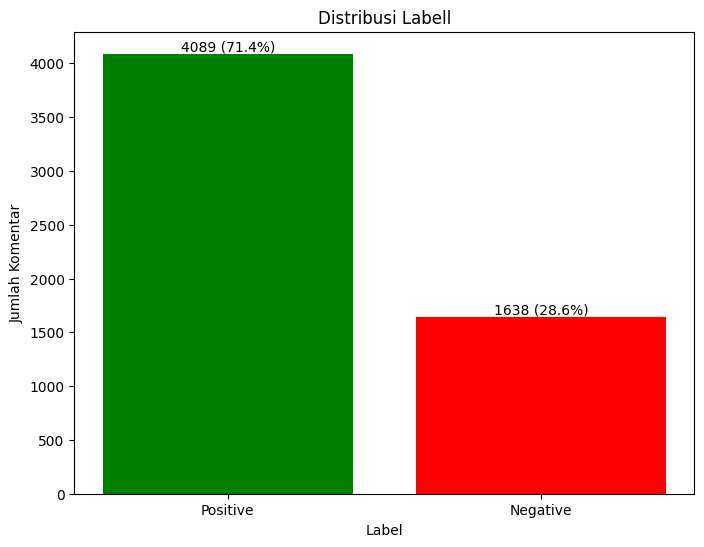

In [ ]:
# Data for the bar chart
labels = ['Positive', 'Negative']
sizes = [len(komentar_positif), len(komentar_negative)]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, sizes, color=['green', 'red'])
plt.title('Distribusi Labell')
plt.xlabel('Label')
plt.ylabel('Jumlah Komentar')

# Add percentage labels on top of each bar
for i, v in enumerate(sizes):
    plt.text(i, v + 1, f'{v} ({100*v/total_komentar:.1f}%)', ha='center', va='bottom')

plt.show()

### 4.2 WordCloud


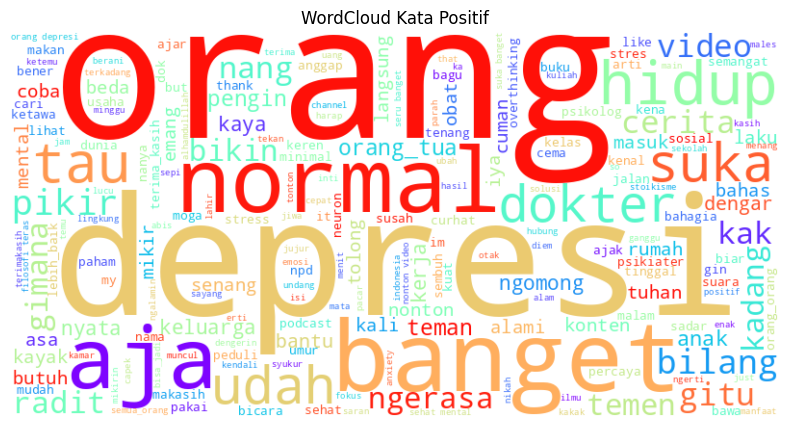

In [ ]:
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud

stopwords_set = set(stopwords.words('indonesian'))

# Pisahkan kata positif dan negatif
kata_positif = []
kata_negatif = []

for kata_list in df['hasil_merge_senticnet']:
    for kata in kata_list:
        polaritas = lexicon_dict.get(kata, 0.0)
        if polaritas >= 0:
            kata_positif.append(kata.lower())
        else :
            kata_negatif.append(kata.lower())

text_positif = ' '.join(kata_positif)
text_negatif = ' '.join(kata_negatif)

wordcloud_pos = WordCloud(
    width=800, height=400, background_color='white',
    stopwords=stopwords_set, colormap='rainbow'
).generate(text_positif)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Kata Positif')
plt.show()

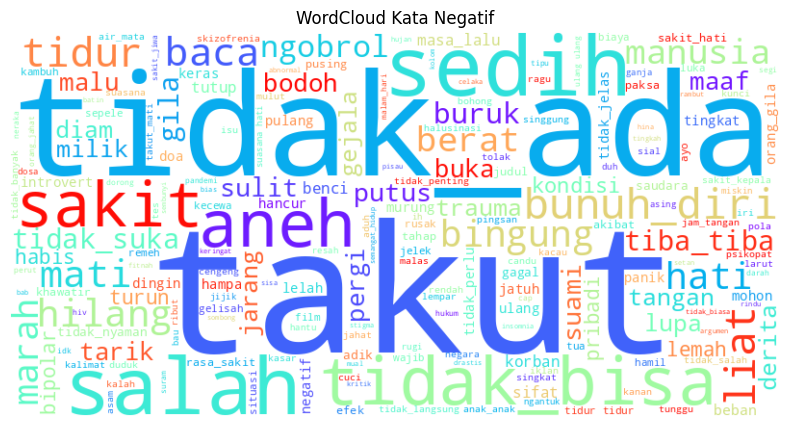

In [ ]:
wordcloud_neg = WordCloud(
    width=800, height=400, background_color='white',
    stopwords=stopwords_set, colormap='rainbow'
).generate(text_negatif)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Kata Negatif')
plt.show()


In [ ]:
df = pd.read_csv('sentimen hasil labeling TA.csv')